In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
from glob import glob
from tqdm import tqdm

sns.set(style="white", context="talk")


In [29]:
b = pd.read_csv("/media/ubuntu/sda/duan/rat/sorting_results/day2/cluster_inf_probe_1.csv")

In [31]:
b['n_spikes']

0    10482
1    25318
2    23454
Name: n_spikes, dtype: int64

In [10]:
SPIKE_RESULTS_ROOT = Path("/media/ubuntu/sda/duan/rat/spike_detection_results")
OUTPUT_DIR = Path("/media/ubuntu/sda/duan/rat/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"结果根目录: {SPIKE_RESULTS_ROOT}")


结果根目录: /media/ubuntu/sda/duan/rat/spike_detection_results


In [110]:
a = pd.read_csv("/media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models/model_5/day2_potential_spikes.csv")

In [111]:
a = a[~a['UMAP_1'].isna()]


In [112]:
pd.crosstab(a['predicted_spike_detection'], a['ground_truth_spike_detection'])

ground_truth_spike_detection,0,1
predicted_spike_detection,,
0,61745,5870
1,19502,12883


In [113]:
a['predicted_spike_classification'].value_counts()

predicted_spike_classification
-1      68030
 196     4482
 287     3933
 174     3903
 297     3680
 261     3671
 309     3094
 202     2529
 289     2170
 195     2110
 293     1537
 182      393
 299      285
 144      183
Name: count, dtype: int64

<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

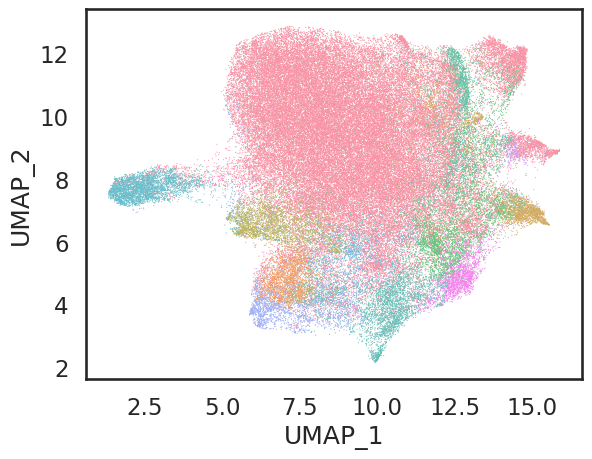

In [114]:
sns.scatterplot(x = a['UMAP_1'],
                y = a['UMAP_2'],
                s = 0.5,
                hue = a['predicted_spike_classification'].astype(str),
                legend=False)

<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

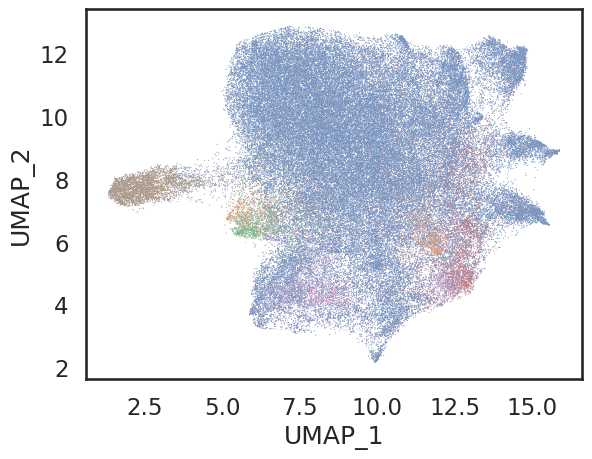

In [115]:
sns.scatterplot(x = a['UMAP_1'],
                y = a['UMAP_2'],
                s = 0.5,
                hue = a['ground_truth_spike_classification'].astype(str),
                legend=False)

<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

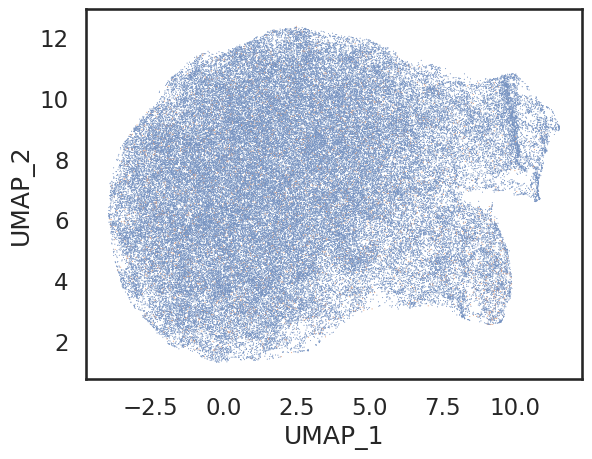

In [93]:
sns.scatterplot(x = a['UMAP_1'],
                y = a['UMAP_2'],
                s = 0.5,
                hue = a['ground_truth_spike_classification'].astype(str),
                legend=False)


In [11]:
def load_all_potential_spikes(root_dir: Path):
    records = []
    for csv_path in tqdm(sorted(root_dir.glob("**/day2_potential_spikes.csv")), desc="加载CSV"):
        relative = csv_path.relative_to(root_dir)
        parts = relative.parts
        probe_model = Path(*parts[:2]).as_posix() if len(parts) >= 2 else relative.as_posix()
        df = pd.read_csv(csv_path)
        df["probe_model"] = probe_model
        df["source_path"] = csv_path.as_posix()
        records.append(df)
    if not records:
        raise FileNotFoundError("未找到任何 day2_potential_spikes.csv 文件")
    return pd.concat(records, ignore_index=True)


def compute_detection_stats(df: pd.DataFrame):
    grouped = []
    for probe_model, subdf in df.groupby("probe_model"):
        gt = subdf["ground_truth_spike_detection"].values
        pred = subdf["predicted_spike_detection"].values
        tp = np.sum((gt == 1) & (pred == 1))
        tn = np.sum((gt == 0) & (pred == 0))
        fp = np.sum((gt == 0) & (pred == 1))
        fn = np.sum((gt == 1) & (pred == 0))
        total = len(subdf)
        accuracy = (tp + tn) / total if total else np.nan
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        tnr = tn / (tn + fp) if (tn + fp) else np.nan
        grouped.append({
            "probe_model": probe_model,
            "n_samples": int(total),
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "accuracy": accuracy,
            "tpr": tpr,
            "tnr": tnr,
        })
    return pd.DataFrame(grouped)


def filter_umap_valid(df: pd.DataFrame):
    mask = df[["UMAP_1", "UMAP_2"]].notna().all(axis=1)
    return df.loc[mask].copy()


def plot_umap_panels(df: pd.DataFrame, probe_model: str, output_dir: Path = OUTPUT_DIR):
    if df.empty:
        print(f"{probe_model}: 无有效 UMAP 数据，跳过绘图")
        return None

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    plots = [
        ("ground_truth_spike_detection", "Ground Truth Detection"),
        ("predicted_spike_detection", "Predicted Detection"),
        ("ground_truth_spike_classification", "Ground Truth Classification"),
        ("predicted_spike_classification", "Predicted Classification"),
    ]

    for ax, (column, title) in zip(axes, plots):
        if column in df.columns:
            scatter = ax.scatter(
                df["UMAP_1"],
                df["UMAP_2"],
                c=df[column],
                cmap="Spectral",
                s=1,
                alpha=0.7,
            )
            fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
            ax.set_title(title)
            ax.set_xlabel("UMAP_1")
            ax.set_ylabel("UMAP_2")
        else:
            ax.set_visible(False)

    plt.suptitle(f"UMAP Scatterplots - {probe_model}", fontsize=18)
    output_path = output_dir / f"{probe_model.replace('/', '_')}_umap_panels.png"
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(output_path, dpi=300)
    plt.close(fig)
    return output_path


In [12]:
all_spikes_df = load_all_potential_spikes(SPIKE_RESULTS_ROOT)
print(f"共加载 {len(all_spikes_df):,} 条记录，来自 {all_spikes_df['probe_model'].nunique()} 个模型")


加载CSV: 100%|██████████| 32/32 [00:06<00:00,  5.11it/s]


共加载 24,397,724 条记录，来自 32 个模型


In [15]:
umap_paths = []
for probe_model, subdf in all_spikes_df.groupby("probe_model"):
    valid_df = filter_umap_valid(subdf)
    path = plot_umap_panels(valid_df, probe_model)
    if path is not None:
        umap_paths.append(path)

print(f"共生成 {len(umap_paths)} 张 UMAP 图，保存至 {OUTPUT_DIR}")


共生成 32 张 UMAP 图，保存至 /media/ubuntu/sda/duan/rat/analysis
